# Day 1 - Laboratory Exercise: Predicting Wine Quality

The walkthrough used 344 penguins, which were clean, small, and well behaved.
This laboratory exercise uses 6497 wines, which are none of those things. The
same sequence of steps applies, but here several of them catch a problem that
would otherwise travel silently into your conclusions.

Each wine has eleven physical and chemical measurements and a quality score
from zero to ten, awarded by the median judgement of at least three wine
tasters. Red and white wines are both present and are marked by a `colour`
column.

## How To Work Through This?

There are seven tasks. Each one states a goal, gives you a cell to write in
that is marked `# YOUR CODE HERE`, and follows it with a check cell. Run the
check cell after you write your answer. It either prints a confirmation or
tells you what is wrong, so you never have to wonder whether you may move on.

Do not skip the questions in the markdown between tasks. Several of them are
the point of the exercise, and the code is only there to produce the evidence.

If you finish early, the final section suggests extensions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path.cwd().parent / "data"
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

def check(condition, success, failure):
    """Report whether a task was completed correctly."""
    print(success if condition else failure)

## Task 1: Load The Data And Look At It

Read `wine_quality.csv` from `DATA_DIR` into a variable called `wine`. Then
answer, for yourself, the questions the walkthrough insisted on. How many rows
are there, are any values missing, and what does `describe` say about the
minimum and maximum of each column.

In [2]:
wine = pd.read_csv(DATA_DIR / "wine_quality.csv")

print("Rows:", len(wine))
print("Missing values:", int(wine.isna().sum().sum()))
wine.describe()

Rows: 6497
Missing values: 0


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [3]:
check(
    "wine" in dir() and len(wine) == 6497 and "quality" in wine.columns,
    "Task 1 complete. 6497 wines loaded.",
    "Not right yet. Expected a DataFrame called `wine` with 6497 rows and a `quality` column.",
)

Task 1 complete. 6497 wines loaded.


## Task 2: Find The Duplicate Rows

The penguin data had one row per bird. This file makes no such promise, because
two different wines with the same eleven measurements and the same score are
recorded as two identical rows.

Count how many rows are exact duplicates of an earlier row. Use
`DataFrame.duplicated`.

In [4]:
n_duplicates = int(wine.duplicated().sum())

print(f"Exact duplicate rows: {n_duplicates} out of {len(wine)}")
print(f"That is {n_duplicates / len(wine):.1%} of the file.")

Exact duplicate rows: 1177 out of 6497
That is 18.1% of the file.


In [5]:
check(
    "n_duplicates" in dir() and n_duplicates == 1177,
    "Task 2 complete. There are 1177 duplicate rows, which is 18% of the file.",
    "Not right yet. Try wine.duplicated().sum().",
)

Task 2 complete. There are 1177 duplicate rows, which is 18% of the file.


Hold on to that number. We return to it in Task 6, where it turns out to change
the headline result of the whole laboratory exercise.

## Task 3: Explore The Target

Produce two things. First, the count of wines at each quality score. Second, a
plot of how quality relates to the measurements, or at least to the one you
suspect matters most.

Before you plot, look at the correlation of every numeric column with
`quality`, sorted. One feature stands out well ahead of the others.

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5


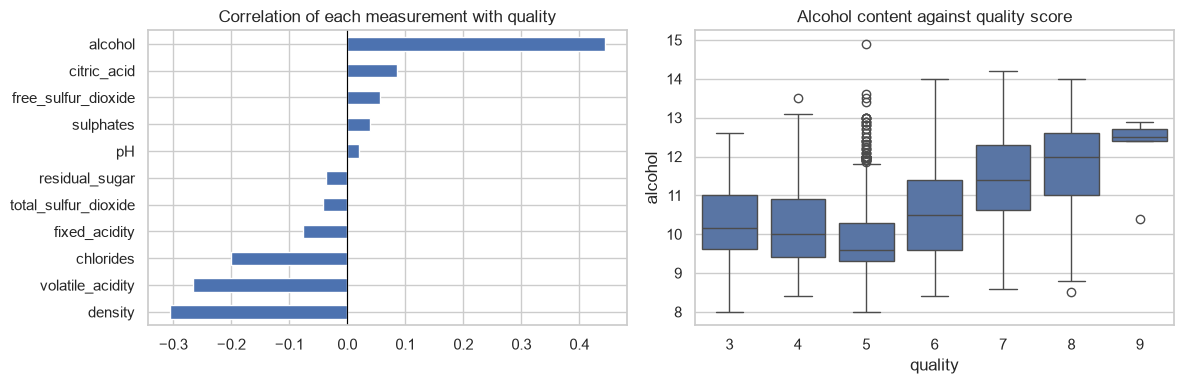

In [6]:
print(wine["quality"].value_counts().sort_index().to_string())

correlations = (
    wine.corr(numeric_only=True)["quality"]
    .drop("quality")
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
correlations.plot.barh(ax=axes[0])
axes[0].set_title("Correlation of each measurement with quality")
axes[0].axvline(0, color="black", linewidth=0.8)

sns.boxplot(data=wine, x="quality", y="alcohol", ax=axes[1])
axes[1].set_title("Alcohol content against quality score")

plt.tight_layout()
plt.show()

In [7]:
check(
    "correlations" in dir() and correlations.abs().idxmax() == "alcohol",
    "Task 3 complete. Alcohol correlates most strongly with quality, at about +0.44.",
    "Not right yet. Build a Series called `correlations` of each numeric column against quality.",
)

Task 3 complete. Alcohol correlates most strongly with quality, at about +0.44.


Two observations are worth making before you continue.

The quality scores are heavily concentrated on 5 and 6, with only 30 wines at
the bottom of the scale and 5 at the top. Any model will see very few examples
of the extremes.

Alcohol correlates with quality at about 0.44, which is the strongest
relationship in the table. Recall Simpson's paradox from the walkthrough, and
notice that this dataset has an obvious grouping variable in `colour`. Checking
whether that correlation survives inside each colour is one of the extensions
at the end.

## Task 4: Predict Quality With Linear Regression

Treat `quality` as a number and fit a linear regression to predict it from the
eleven measurements. Exclude `colour`, which is text, and of course exclude
`quality` itself.

Split the data first, holding back 20 percent with `random_state=RANDOM_STATE`.
Report mean absolute error and R squared, and print the same two numbers for a
`DummyRegressor` that always predicts the training mean.

In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

feature_names = [c for c in wine.columns if c not in ("quality", "colour")]

X = wine[feature_names]
y = wine["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

for label, estimator in [
    ("always the mean", DummyRegressor(strategy="mean")),
    ("linear regression", LinearRegression()),
]:
    estimator.fit(X_train, y_train)
    predicted = estimator.predict(X_test)
    print(
        f"{label:<20s} MAE {mean_absolute_error(y_test, predicted):.3f}   "
        f"R2 {r2_score(y_test, predicted):6.3f}"
    )

linear_r2 = r2_score(y_test, LinearRegression().fit(X_train, y_train).predict(X_test))

always the mean      MAE 0.669   R2 -0.001
linear regression    MAE 0.566   R2  0.260


In [9]:
check(
    "linear_r2" in dir() and 0.20 < linear_r2 < 0.32,
    "Task 4 complete. Linear regression reaches an R squared of about 0.26.",
    "Not right yet. Expected an R squared between 0.20 and 0.32 on the held-out wines.",
)

Task 4 complete. Linear regression reaches an R squared of about 0.26.


The model beats the baseline, but only just, and an R squared of 0.26 means it
accounts for about a quarter of the variation in quality. Eleven chemical
measurements do not determine what a panel of tasters thinks of a wine. That is
a real finding rather than a failure of the method, and reporting it plainly is
better practice than hunting for a model that appears to do better.

## Task 5: Turn It Into A Classification Problem And Watch Accuracy Mislead You

Define a good wine as one scoring 7 or above, and build a binary target called
`is_good`. Then fit a logistic regression to predict it.

Remember two things from the walkthrough. Logistic regression needs its
features standardised, which you should do inside a `Pipeline` rather than by
hand. And `stratify` the split so both parts hold the same proportion of good
wines.

Print the accuracy. Then print `classification_report`, and print the accuracy
of a `DummyClassifier` using `strategy="most_frequent"`.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

is_good = (wine["quality"] >= 7).astype(int)
print(f"Share of wines rated good: {is_good.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, is_good, test_size=0.2, random_state=RANDOM_STATE, stratify=is_good
)

majority = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
logistic = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_train, y_train)

print(f"\nalways predict 'not good': accuracy {majority.score(X_test, y_test):.3f}")
print(f"logistic regression:       accuracy {logistic.score(X_test, y_test):.3f}")

print(f"\n{classification_report(y_test, logistic.predict(X_test), target_names=['not good', 'good'])}")

logistic_accuracy = logistic.score(X_test, y_test)

Share of wines rated good: 19.7%

always predict 'not good': accuracy 0.803
logistic regression:       accuracy 0.822

              precision    recall  f1-score   support

    not good       0.84      0.96      0.90      1044
        good       0.61      0.26      0.37       256

    accuracy                           0.82      1300
   macro avg       0.73      0.61      0.63      1300
weighted avg       0.80      0.82      0.79      1300



In [11]:
check(
    "logistic_accuracy" in dir() and 0.78 < logistic_accuracy < 0.86,
    "Task 5 complete. Now read the recall for the 'good' class before you continue.",
    "Not right yet. Expected an accuracy between 0.78 and 0.86.",
)

Task 5 complete. Now read the recall for the 'good' class before you continue.


### Stop And Read The Report

The logistic regression scores about 0.82 accuracy. A model that ignores every
measurement and calls every wine not good scores about 0.80. The difference
between doing real work and doing nothing at all is two percentage points.

Now look at the recall on the good class, which is about 0.26. Of every four
genuinely good wines, the model finds one and misses three. Accuracy hid that
completely, because 80 percent of the wines are not good and getting those
right is enough to look respectable.

This is why the walkthrough insisted on a baseline. Whenever one class is much
larger than the other, accuracy measures the size of the majority class more
than it measures the model.

## Task 6: Random Forests And An Honest Estimate

Fit a `RandomForestClassifier` with 300 trees on the same task and print its
accuracy, precision, recall, and F1 for the good class.

Then evaluate it a second way, with 5-fold cross validation scored on F1. Use
`StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)`. The
shuffle matters here: this file has all the red wines first and all the whites
after them, so folds taken without shuffling are not representative.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

forest = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
forest.fit(X_train, y_train)
predicted = forest.predict(X_test)

print(f"accuracy  {forest.score(X_test, y_test):.3f}")
print(f"precision {precision_score(y_test, predicted):.3f}")
print(f"recall    {recall_score(y_test, predicted):.3f}")
print(f"F1        {f1_score(y_test, predicted):.3f}")

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1 = cross_val_score(forest, X, is_good, cv=folds, scoring="f1")

print(f"\ncross validated F1: {cv_f1.mean():.3f}  (per fold: {cv_f1.round(3)})")

forest_f1 = f1_score(y_test, predicted)

accuracy  0.888
precision 0.806
recall    0.566
F1        0.665



cross validated F1: 0.669  (per fold: [0.616 0.677 0.663 0.677 0.709])


In [13]:
check(
    "forest_f1" in dir() and forest_f1 > 0.55,
    "Task 6 complete. The forest reaches an F1 near 0.66, far above the logistic regression's 0.37.",
    "Not right yet. Expected an F1 above 0.55 for the random forest.",
)

Task 6 complete. The forest reaches an F1 near 0.66, far above the logistic regression's 0.37.


### The Result Is Too Good And Task 2 Explains Why

The forest reports an F1 around 0.66 both on the held-out set and under cross
validation. Two independent estimates agreeing is normally reassuring.

They agree because they share the same flaw. Recall the 1177 duplicate rows you
counted in Task 2. A random split puts some copies of a duplicated wine in the
training set and its twin in the test set. The forest, which is perfectly
capable of memorising individual rows, then recognises a wine it has already
seen. That is not prediction, it is recall of the training data, and it
inflates every score computed this way.

Cross validation did not save us, because it splits randomly too.

## Task 7: Measure It Again Without The Leak

Remove the duplicate rows with `drop_duplicates`, then repeat both evaluations
from Task 6 on the deduplicated data. Report the held-out F1 and the cross
validated F1.

In [14]:
unique_wine = wine.drop_duplicates().reset_index(drop=True)
print(f"Rows before: {len(wine)}, after removing duplicates: {len(unique_wine)}")

X_unique = unique_wine[feature_names]
y_unique = (unique_wine["quality"] >= 7).astype(int)

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unique, y_unique, test_size=0.2, random_state=RANDOM_STATE, stratify=y_unique
)

honest_forest = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
honest_forest.fit(X_train_u, y_train_u)
honest_f1 = f1_score(y_test_u, honest_forest.predict(X_test_u))

honest_cv = cross_val_score(honest_forest, X_unique, y_unique, cv=folds, scoring="f1")

print(f"\n{'':<22s}{'with duplicates':>18s}{'deduplicated':>18s}")
print(f"{'held-out F1':<22s}{forest_f1:>18.3f}{honest_f1:>18.3f}")
print(f"{'cross validated F1':<22s}{cv_f1.mean():>18.3f}{honest_cv.mean():>18.3f}")

Rows before: 6497, after removing duplicates: 5320



                         with duplicates      deduplicated
held-out F1                        0.665             0.471
cross validated F1                 0.669             0.475


In [15]:
check(
    "honest_f1" in dir() and 0.40 < honest_f1 < 0.55,
    "Task 7 complete. The honest F1 is near 0.47, about seven tenths of what the leak suggested.",
    "Not right yet. Expected a held-out F1 between 0.40 and 0.55 after deduplicating.",
)

Task 7 complete. The honest F1 is near 0.47, about seven tenths of what the leak suggested.


### What Just Happened?

The model did not change. The data did not change in any way that a chemist
would recognise. Removing rows that were counted twice dropped the F1 from
about 0.66 to about 0.47.

Had you reported the first number, you would have overstated the model's
performance by about thirty percent. Nothing in the modelling code was wrong.
The error was made in Task 2, at the moment the duplicates were counted and
then ignored.

This is the most important thing in today's session. Most published failures of
applied machine learning are not exotic. They are a train and test set that
were not as separate as somebody assumed.

## Extensions

Each of these is worked through below.

1. Check Simpson's paradox on this data. Compute the correlation between
   alcohol and quality overall, then again separately for red and for white.
   Does the relationship hold up inside each colour?
2. The good class is only 19 percent of the data. Refit the forest with
   `class_weight="balanced"` and see what it does to precision and recall.
   Which of the two improves, and which gets worse?
3. Instead of using a threshold of 0.5 on the forest's probabilities, sweep the
   threshold and plot precision and recall against it. Pick the threshold you
   would choose if the goal were to shortlist wines for a human to taste, and
   justify it in a sentence.
4. Add `colour` as a feature, encoded with `get_dummies`. Does knowing whether
   a wine is red or white help predict its quality?
5. Print the forest's `feature_importances_`. Compare the ranking against the
   correlations you computed in Task 3, and explain any feature that ranks high
   in one and low in the other.

### Extension 1: Simpson's Paradox On Alcohol And Quality

The walkthrough showed a correlation that reversed sign once the penguins were
split by species. The wines have an obvious grouping variable in `colour`, so
the same check is worth running here. All of the extensions work on
`unique_wine`, because after Task 7 there is no reason to go back to the
duplicated file.

In [16]:
groups = [("all wines", unique_wine)] + list(unique_wine.groupby("colour"))

print(f"{'group':<12s}{'wines':>8s}{'correlation':>14s}{'mean alcohol':>15s}{'mean quality':>15s}")
for label, group in groups:
    print(
        f"{label:<12s}{len(group):>8d}"
        f"{group['alcohol'].corr(group['quality']):>14.3f}"
        f"{group['alcohol'].mean():>15.2f}{group['quality'].mean():>15.2f}"
    )

group          wines   correlation   mean alcohol   mean quality
all wines       5320         0.469          10.55           5.80
red             1359         0.480          10.43           5.62
white           3961         0.463          10.59           5.85


The relationship survives. Alcohol correlates with quality at about 0.47 over
all the wines, 0.48 among the reds, and 0.46 among the whites, so the pooled
figure is an honest summary of both groups rather than an artefact of mixing
them.

The reason the paradox does not appear is visible in the last two columns. Reds
and whites sit at almost the same mean alcohol, so the grouping variable is
nearly independent of the feature, and a group difference that does not shift
the feature cannot reverse its slope. Contrast that with the penguins, where
the species differed enormously in both bill dimensions.

Note also that the pooled correlation here is 0.469 rather than the 0.444
reported in Task 3, because the duplicates are gone. Deduplicating changes
descriptive statistics as well as model scores.

### Extension 2: Refitting The Forest With Balanced Class Weights

Good wines are about 19 percent of the data, and `class_weight="balanced"`
tells the forest to weight each class in inverse proportion to how often it
appears. The usual expectation is that this buys recall on the rare class at
some cost in precision.

In [17]:
from sklearn.metrics import average_precision_score

balanced_forest = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
).fit(X_train_u, y_train_u)

print(f"{'':<12s}{'precision':>11s}{'recall':>9s}{'F1':>7s}{'flagged':>9s}{'avg prec':>10s}")
for label, model in [("default", honest_forest), ("balanced", balanced_forest)]:
    predicted_u = model.predict(X_test_u)
    probabilities = model.predict_proba(X_test_u)[:, 1]
    print(
        f"{label:<12s}{precision_score(y_test_u, predicted_u):>11.3f}"
        f"{recall_score(y_test_u, predicted_u):>9.3f}{f1_score(y_test_u, predicted_u):>7.3f}"
        f"{predicted_u.sum():>9d}{average_precision_score(y_test_u, probabilities):>10.3f}"
    )

print(f"\nGood wines actually present in the test set: {int(y_test_u.sum())} of {len(y_test_u)}.")

              precision   recall     F1  flagged  avg prec
default           0.676    0.361  0.471      108     0.619
balanced          0.592    0.639  0.614      218     0.639

Good wines actually present in the test set: 202 of 1064.


The expectation holds. Recall rises from about 0.36 to about 0.64 while
precision falls from about 0.68 to about 0.59, so the balanced forest finds
nearly twice as many of the good wines and is wrong more often when it points
at one. F1 improves from 0.471 to 0.614, though that follows from F1 weighting
precision and recall equally rather than from any judgement about which of them
this application needs.

The last column is the one to read carefully. Average precision summarises how
well a model ranks wines by probability without committing to any cut, and it
barely moves, going from 0.619 to 0.639. The two forests order the test wines
about equally well. Reweighting taught the model nothing new about wine. It
shifted where the probabilities fall relative to the fixed cut at 0.5, and the
entire change in precision and recall follows from that shift.

The lesson is that `class_weight` is an indirect way to move an operating
point. It moves it in the useful direction here, but you did not choose the
size of the move and nothing guarantees the direction on another dataset. If
you want a particular balance of precision and recall, set the threshold
yourself, which is exactly what the next extension does.

### Extension 3: Choosing A Threshold Instead Of Accepting 0.5

`predict` applies a cut at 0.5 to the probabilities from `predict_proba`.
Nothing about the problem makes 0.5 the right cut, so sweep it and look at what
each choice costs.

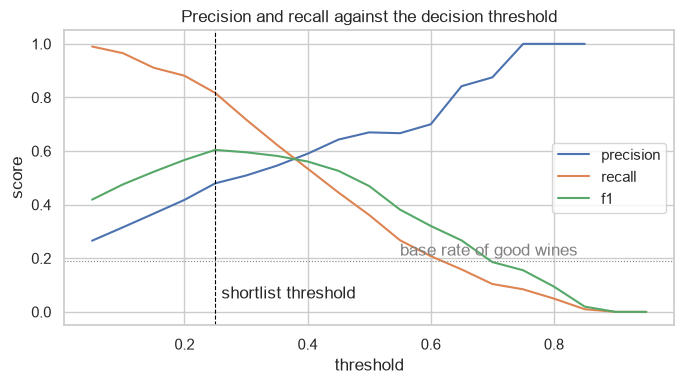

           precision  recall     f1  flagged
threshold                                   
0.15           0.367   0.911  0.523      502
0.20           0.418   0.881  0.567      426
0.25           0.480   0.817  0.604      344
0.30           0.509   0.718  0.595      285
0.35           0.545   0.624  0.582      231
0.40           0.590   0.535  0.561      183
0.45           0.643   0.446  0.526      140
0.50           0.670   0.361  0.469      109
0.55           0.667   0.267  0.382       81


In [18]:
probabilities = honest_forest.predict_proba(X_test_u)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.05)

sweep = pd.DataFrame(
    [
        {
            "threshold": t,
            "precision": precision_score(y_test_u, probabilities >= t, zero_division=np.nan),
            "recall": recall_score(y_test_u, probabilities >= t),
            "f1": f1_score(y_test_u, probabilities >= t),
            "flagged": int((probabilities >= t).sum()),
        }
        for t in thresholds
    ]
).set_index("threshold")

fig, ax = plt.subplots(figsize=(7, 4))
sweep[["precision", "recall", "f1"]].plot(ax=ax)
ax.axvline(0.25, color="black", linestyle="--", linewidth=0.8)
ax.axhline(y_test_u.mean(), color="grey", linestyle=":", linewidth=0.8)
ax.set_title("Precision and recall against the decision threshold")
ax.set_ylabel("score")
ax.annotate("shortlist threshold", xy=(0.26, 0.05))
ax.annotate("base rate of good wines", xy=(0.55, y_test_u.mean() + 0.02), color="grey")
plt.tight_layout()
plt.show()

print(sweep.loc[0.15:0.55].round(3).to_string())

For a shortlist that a person will taste, 0.25 is a defensible choice. It finds
about 80 percent of the genuinely good wines instead of the 36 percent that 0.5
finds, and it does so by asking somebody to taste 344 of the 1064 test wines,
of which about 48 percent are good against a base rate of 19 percent. Missing a
good wine is the expensive error here and tasting a mediocre one is cheap, so
recall is worth buying at that price.

The dotted grey line is the base rate, and precision falls towards it as the
threshold falls, because flagging every wine gives a shortlist that is exactly
as good as the cellar it came from. That line is the floor the model has to
beat to be worth running at all. The precision curve stops above 0.85 because
beyond that the forest flags no wines, and a precision computed over an empty
shortlist does not exist.

Two cautions apply. The threshold was chosen by looking at the test set, so the
numbers above are optimistic as an estimate of what it would do on new wines,
and a threshold picked properly is picked on a validation split. And F1 peaks
around 0.25 to 0.30 here, which is convenient but coincidental. The right
threshold comes from the relative cost of the two errors, not from whichever
value maximises a summary score.

### Extension 4: Adding Colour As A Feature

Every model so far dropped `colour` because it is text. One-hot encoding turns
it into a column the forest can use, so it is worth asking whether knowing red
from white helps.

In [19]:
with_colour = pd.get_dummies(
    unique_wine.drop(columns=["quality"]), columns=["colour"], drop_first=True
)
print("Columns:", list(with_colour.columns))

forest_template = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
without_cv = cross_val_score(forest_template, X_unique, y_unique, cv=folds, scoring="f1")
with_cv = cross_val_score(forest_template, with_colour, y_unique, cv=folds, scoring="f1")

print(f"\n{'':<22s}{'mean F1':>10s}   per fold")
print(f"{'eleven measurements':<22s}{without_cv.mean():>10.3f}   {without_cv.round(3)}")
print(f"{'plus colour':<22s}{with_cv.mean():>10.3f}   {with_cv.round(3)}")

colour_forest = forest_template.fit(with_colour, y_unique)
importance_with_colour = pd.Series(
    colour_forest.feature_importances_, index=with_colour.columns
).sort_values(ascending=False)
print(f"\nImportance of colour_white: {importance_with_colour['colour_white']:.4f}, "
      f"ranked {list(importance_with_colour.index).index('colour_white') + 1} of {len(importance_with_colour)}.")

Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'colour_white']



                         mean F1   per fold
eleven measurements        0.475   [0.52  0.425 0.477 0.468 0.485]
plus colour                0.468   [0.511 0.42  0.455 0.46  0.497]



Importance of colour_white: 0.0028, ranked 12 of 12.


Colour does not help. The cross validated F1 moves from about 0.475 to about
0.468, which is a change smaller than the spread between folds, and the new
column ranks last of the twelve by importance at about 0.003.

That is the expected answer once you think about what the other columns already
contain. Total sulphur dioxide correlates with being white at about 0.69 and
volatile acidity at about minus 0.65, so the chemistry identifies the colour
well enough that stating it adds nothing. A feature is only useful when it
carries information the other features do not.

### Extension 5: Feature Importances Against The Correlations

The correlations in Task 3 and the forest's importances both rank the features,
and comparing the two rankings shows what each measure can and cannot see.

In [20]:
comparison = pd.DataFrame(
    {
        "importance": pd.Series(honest_forest.feature_importances_, index=feature_names),
        "abs_correlation": correlations.abs(),
    }
)
comparison["importance_rank"] = comparison["importance"].rank(ascending=False).astype(int)
comparison["correlation_rank"] = comparison["abs_correlation"].rank(ascending=False).astype(int)
print(comparison.sort_values("importance", ascending=False).round(3).to_string())

quintiles = pd.qcut(unique_wine["total_sulfur_dioxide"], 5)
print("\nMean quality by quintile of total sulphur dioxide:")
print(unique_wine.groupby(quintiles, observed=True)["quality"].mean().round(3).to_string())

                      importance  abs_correlation  importance_rank  correlation_rank
alcohol                    0.170            0.444                1                 1
density                    0.121            0.306                2                 2
chlorides                  0.088            0.201                3                 4
total_sulfur_dioxide       0.084            0.041                4                 8
volatile_acidity           0.083            0.266                5                 3
residual_sugar             0.081            0.037                6                10
sulphates                  0.081            0.038                7                 9
free_sulfur_dioxide        0.079            0.055                8                 7
pH                         0.075            0.020                9                11
citric_acid                0.071            0.086               10                 5
fixed_acidity              0.066            0.077               1

The two rankings agree at the top. Alcohol and density lead both, and the two
are almost the same variable, correlating at about minus 0.67, because alcohol
is lighter than water.

They disagree most on total sulphur dioxide, which the forest ranks fourth
while the correlation ranks it eighth at a nearly invisible 0.041. The quintile
table shows why. Mean quality rises from 5.68 in the lowest fifth to 6.01 in
the middle fifth, then falls to 5.54 in the highest. The relationship is a
hump, and a correlation coefficient measures only the straight-line part of a
relationship, which for a symmetric hump is close to nothing. A tree splits
wherever it likes and can use both halves of the curve. Residual sugar and pH
show a milder version of the same shape, which is why they too rank higher by
importance than by correlation.

Citric acid moves the other way, ranking fifth by correlation and tenth by
importance. Part of that is shared information, since citric acid correlates
with fixed acidity at about 0.33 and with pH at about minus 0.34, and an
importance describes what a feature added alongside the others rather than what
it says on its own. The larger part is that neither ranking has much to
separate below the top two. Every importance from third place down falls
between 0.066 and 0.088, and the absolute correlations over the same features
run from 0.020 to 0.201, so a gap of five places there is not a meaningful
difference in usefulness.

Neither number is a measure of causation. Both describe a chemical panel and a
committee of tasters, and neither says that adding alcohol to a wine would make
anyone like it more.

## What To Take Away?

- Count the duplicate rows before you split. A random split over duplicated
  data leaks the test set into training, and both the held-out score and cross
  validation will agree with each other while both being wrong.
- Print a baseline next to every score. On imbalanced data, accuracy mostly
  measures the size of the majority class.
- Read precision and recall separately, and decide which one your application
  actually cares about before you look at either.
- Shuffle before cross validating whenever the rows arrived in a meaningful
  order.
- A model that explains a quarter of the variation, reported honestly, is worth
  more than one that appears to explain two thirds because of a leak.